In [2]:
# ============================================================
# CELL 1 – Imports
# ============================================================
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.set_default_dtype(torch.float64)   # use float64 for numerical stability

In [4]:
# ============================================================
# CELL 2 – Load data
# ============================================================
data   = pd.read_csv("Nicaragua_Data.csv")
C_raw_NTU  = data["Turbiedad (UNT)"].values   # raw turbidity  [NTU]
C_coag_mgL = data["Dosis (mg/L)"].values       # coagulant dose [mg/L as Al]
N          = len(C_raw_NTU)

print(f"Loaded {N} data points")
print(f"  Turbidity : {C_raw_NTU.min():.1f} – {C_raw_NTU.max():.1f} NTU")
print(f"  Dose      : {C_coag_mgL.min():.2f} – {C_coag_mgL.max():.2f} mg/L")

Loaded 37 data points
  Turbidity : 1.9 – 650.0 NTU
  Dose      : 6.00 – 35.00 mg/L


In [ ]:
# ============================================================
# CELL 3 – Configuration
# Edit values here
# ============================================================

# ── Training ─────────────────────────────────────────────────
EPOCHS    = 4000
LR        = 3e-3
LOG_EVERY = 400
SEED      = 42

# ── Design target ─────────────────────────────────────────────
# The Nicaragua plant was dosing to achieve roughly 1 NTU clarified water.
# Adjust this if you know the actual plant target.
C_TARGET_NTU = 1.0   # [NTU]

# ── Unit conversion ───────────────────────────────────────────
# 1 NTU ≈ 1.47 mg/L for kaolinite (textbook: 68 NTU ≈ 100 mg/L kaolinite)
# TODO: double check source
# 1 mg/L = 1e-3 g/L = 1e-3 kg/m³
NTU_TO_KG_M3  = 1.47e-3   # [kg/m³ per NTU]
MGL_TO_KG_M3  = 1.0e-3    # [kg/m³ per mg/L]

# ── Fixed physical constants (SI units) ───────────────────────
PI      = math.pi
RHO_P   = 1500.0      # kg/m³  – primary particle (clay) density
RHO_C   = 1138.0      # kg/m³  – coagulant nanoparticle (PACl) density
H_FF    = 1.0         # m      – floc filter / floc blanket height
# TODO: set G and theta as constant
# 15 minutes for theta, 35,000 for G-theta, 39 for G

# ── Initial parameter values (SI units: m, kg, s) ─────────────
# TODO: Verify initialization values
INIT = {
    "k"              : 0.66,       # flocculation fitting constant  (dimensionless)
    "G"              : 10.0,       # velocity gradient              [1/s]
    "theta_t"        : 15 * 60.0, # HRT of flocculator             [s]
    "r_p"            : 1.0e-6,    # primary particle radius        [m] = 1 µm
    "r_c"            : 45.0e-9,   # coagulant nanoparticle radius  [m] = 45 nm
    "r_floc"         : 1.0e-3,    # floc radius in clarifier       [m] = 1 mm
    "C_floc_blanket" : 2.0,       # floc blanket concentration     [kg/m³] ≈ 2 g/L
                                   # (textbook: typical 1–5 g/L)
    "C_dom"          : 1.0e-3,       # DOM concentration              [kg/m³]
}

torch.manual_seed(SEED)

In [9]:
# ============================================================
# CELL 4 – Model
# ============================================================

class FlocClarifyModel(nn.Module):
    """
    Differentiable flocculation → clarification model.

    All parameters are stored in log-space (exp'd on use) so they
    stay positive regardless of how large a gradient step is taken.
    """
    def __init__(self):
        super().__init__()
        for name, val in INIT.items():
            setattr(self, f"log_{name}",
                    nn.Parameter(torch.tensor(math.log(val))))

    # ── Positive-value properties ─────────────────────────────
    @property
    def k(self):              return torch.exp(self.log_k)
    @property
    def G(self):              return torch.exp(self.log_G)
    @property
    def theta_t(self):        return torch.exp(self.log_theta_t)
    @property
    def r_p(self):            return torch.exp(self.log_r_p)
    @property
    def r_c(self):            return torch.exp(self.log_r_c)
    @property
    def r_floc(self):         return torch.exp(self.log_r_floc)
    @property
    def C_floc_blanket(self): return torch.exp(self.log_C_floc_blanket)
    @property
    def C_dom(self): return torch.exp(self.log_C_dom)

    def forward(self, C_raw_mass, C_coag_mass):
        """
        Parameters
        ----------
        C_raw_mass  : (N,) raw water concentration  [kg/m³]
                      (converted from NTU via NTU_TO_KG_M3)
        C_coag_mass : (N,) coagulant concentration  [kg/m³]
                      (converted from mg/L via MGL_TO_KG_M3)

        Returns
        -------
        C_clarified_mass : (N,) predicted clarified turbidity [kg/m³]
        """
        r_p, r_c    = self.r_p, self.r_c
        r_floc      = self.r_floc
        k, G, theta = self.k, self.G, self.theta_t
        C_dom = self.C_dom

        # ── STEP 1: Coagulant surface coverage Γ  ─────────────
        #
        # Γ_PACl-Clay = fraction of clay surface covered by PACl nanoparticles.
        #
        # Derivation (textbook §7, eq 185 adapted for clay-PACl):
        #   Γ = (projected area of one coagulant on clay) × N_coag
        #       ───────────────────────────────────────────────────
        #       (surface area of one clay particle)        × N_clay
        #
        #     = (π r_c²) / (4π r_p²)  ×  N_coag / N_clay
        #
        # where N = C / (ρ · (4/3)π r³), so N_coag/N_clay = (C_coag/C_raw) · (ρ_p r_p³)/(ρ_c r_c³)
        #
        # Substituting:
        #   Γ = [r_c² / (4 r_p²)] · (C_coag/C_raw) · (ρ_p r_p³)/(ρ_c r_c³)
        #     = (C_coag / C_raw) · ρ_p r_p / (4 ρ_c r_c)
        #
        # So:  k_1 = ρ_p · r_p / (4 · ρ_c · r_c)   [dimensionless]
        #
        # NOTE: This is equivalent to m_p·r_c² / (4·m_c·(r_p)²)
        
        k_1  = (RHO_P * r_p) / (4.0 * RHO_C * r_c)                      # dimensionless
        Gamma = torch.clamp(k_1 * (C_coag_mass - C_dom) / C_raw_mass,   # dimensionless
                            0.0, 1.0)

        # ── STEP 2: Flocculation → C_flocculated  ─────────────
        #
        # AguaClara flocculation model (Pennock et al. 2018, eq 177):
        #
        #   (3/2π) · (ρ_p·π/6)^(2/3) · [C_floc^(-2/3) - C_raw^(-2/3)] = k·Γ·G·θ
        #
        # Rearranged:
        #   C_floc^(-2/3) = C_raw^(-2/3) + Γ / k_pf
        #
        #   where k_pf = (3 / (2π·k·G·θ)) · (ρ_p·π/6)^(2/3)   [(kg/m³)^(2/3)]
        #
        # Physical meaning: k_pf captures how quickly floc growth reduces
        # the primary-particle concentration given the flocculator conditions.
        # Larger G·θ → more collisions → smaller k_pf → lower C_flocculated.
        #
        # NOTE: k_pf is defined slightly differently here than in the SP25 model
        # (k' was incorporated into Γ instead of k_pf)

        k_pf = (3.0 / (2.0 * PI * k * G * theta)) * ((RHO_P * PI / 6.0) ** (2.0 / 3.0))

        C_flocculated = (C_raw_mass ** (-2.0 / 3.0)
                         + Gamma / k_pf) ** (-1.5)            # [kg/m³]

        # ── STEP 3: Clarification ───────────────────────────
        #
        # Reference: "Clarification Model: Floc Separation Distance"
        #
        # The clarifier floc blanket is modelled as a grid of cubic boxes of
        # side-length Λ, each containing one floc of radius r_floc.
        #
        # Per-box removal of primary particles (eq 9 in the PDF):
        #   C_p(h + Λ) = C_p(h) · [1 − α·π·(3φ/(4π))^(2/3)]
        #
        # where:
        #   α       = Γ (same attachment efficiency as in flocculation)
        #   FIXME: alpha should include floc saturation/fluid deflection effects
        #   φ_floc  = volume fraction of flocs in blanket = C_floc_blanket / ρ_p
        #   Λ       = floc separation distance = (m_floc / C_floc_blanket)^(1/3)
        #   m_floc  = ρ_p · (4/3)·π·r_floc³   (mass of one floc sphere)
        # 
        # After h_ff / Λ boxes (geometric series, eq 10):
        #   C_clarified = C_flocculated · (1 − α·π·(3φ/(4π))^(2/3)) ^ (h_ff / Λ)
        #
        # NOTE: C_floc_blanket is the concentration of flocs INSIDE the blanket,
        # a design-level quantity independent of C_flocculated.

        # Volume fraction of flocs in the blanket (dimensionless)
        phi_floc = self.C_floc_blanket / RHO_P

        # Mass of one floc (treating it as a solid sphere of primary-particle density)
        # FIXME: This needs to at a minimum incorporate fractal dimension
        m_floc = RHO_P * (4.0 / 3.0) * PI * r_floc ** 3      # [kg]

        # Floc separation distance
        Lambda = (m_floc / self.C_floc_blanket) ** (1.0 / 3.0) # [m]

        # Fraction of primary particles captured per Λ-thick layer
        p = Gamma * PI * (3.0 * phi_floc / (4.0 * PI)) ** (2.0 / 3.0)
        p = torch.clamp(p, 0.0, 1.0 - 1e-8)                  # keep (1-p)^n stable

        # Number of Λ-layers spanning the floc filter height
        n_boxes = H_FF / Lambda                                # dimensionless

        # Clarified turbidity after passing through the full floc filter
        C_clarified = C_flocculated * (1.0 - p) ** n_boxes    # [kg/m³]

        return C_clarified

In [10]:
# ============================================================
# CELL 5 – Convert data and run training
# ============================================================

# Convert data to SI concentrations [kg/m³]
C_raw_t   = torch.tensor(C_raw_NTU  * NTU_TO_KG_M3)
C_coag_t  = torch.tensor(C_coag_mgL * MGL_TO_KG_M3)
C_target_t = torch.full((N,), C_TARGET_NTU * NTU_TO_KG_M3)

model     = FlocClarifyModel()
optimiser = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=EPOCHS)
mse_fn    = nn.MSELoss()

history   = {"epoch": [], "loss": []}

print(f"\nTarget clarified turbidity : {C_TARGET_NTU} NTU")
print(f"{'Epoch':>6}  {'MSE loss':>12}")
print("-" * 25)

for epoch in range(1, EPOCHS + 1):
    optimiser.zero_grad()

    C_clarified_pred = model(C_raw_t, C_coag_t)   # [kg/m³]

    loss = mse_fn(C_clarified_pred, C_target_t)    # both in kg/m³
    loss.backward()
    optimiser.step()
    scheduler.step()

    if epoch % LOG_EVERY == 0 or epoch == 1:
        history["epoch"].append(epoch)
        history["loss"].append(loss.item())
        # Convert loss to NTU² for readability
        loss_ntu2 = loss.item() / NTU_TO_KG_M3**2
        print(f"{epoch:>6}  {loss_ntu2:>12.4f}  NTU²")

print("\nTraining complete.")


Target clarified turbidity : 1.0 NTU
 Epoch      MSE loss
-------------------------
     1        0.6098  NTU²
   400        0.0412  NTU²
   800        0.0371  NTU²
  1200        0.0348  NTU²
  1600        0.0334  NTU²
  2000        0.0326  NTU²
  2400        0.0321  NTU²
  2800        0.0318  NTU²
  3200        0.0317  NTU²
  3600        0.0316  NTU²
  4000        0.0316  NTU²

Training complete.


In [ ]:
# ============================================================
# CELL 6 – Results
# ============================================================

model.eval()
with torch.no_grad():
    C_clarified_pred = model(C_raw_t, C_coag_t).numpy()

# Convert back to NTU for display
C_clarified_NTU = C_clarified_pred / NTU_TO_KG_M3

optimised = {name: torch.exp(getattr(model, f"log_{name}")).item()
             for name in INIT}

print("\n" + "=" * 62)
print(f"  {'Parameter':<16}  {'Initial':>14}  {'Optimised':>14}  {'Δ%':>7}")
print("=" * 62)
for name in INIT:
    init_val = INIT[name]
    opt_val  = optimised[name]
    pct      = (opt_val - init_val) / init_val * 100
    print(f"  {name:<16}  {init_val:>14.4g}  {opt_val:>14.4g}  {pct:>+6.1f}%")
print("=" * 62)

rmse_ntu = float(np.sqrt(np.mean((C_clarified_NTU - C_TARGET_NTU)**2)))
print(f"\n  RMSE of C_clarified vs {C_TARGET_NTU} NTU target : {rmse_ntu:.4f} NTU")
print(f"  Mean predicted C_clarified                 : {C_clarified_NTU.mean():.4f} NTU")

# Save
pd.DataFrame([optimised]).to_csv("optimised_params_v2.csv", index=False)
# print("  Saved → optimised_params_v2.csv")


  Parameter                Initial       Optimised       Δ%
  k                           0.66          0.5077   -23.1%
  G                             10           7.693   -23.1%
  theta_t                      900           692.3   -23.1%
  r_p                        1e-06       1.956e-06   +95.6%
  r_c                      4.5e-08       2.301e-08   -48.9%
  r_floc                     0.001        0.003339  +233.9%
  C_floc_blanket                 2          0.5998   -70.0%
  C_dom                      0.001       0.0007349   -26.5%

  RMSE of C_clarified vs 1.0 NTU target : 0.1777 NTU
  Mean predicted C_clarified                 : 0.9534 NTU
  Saved → optimised_params_v2.csv


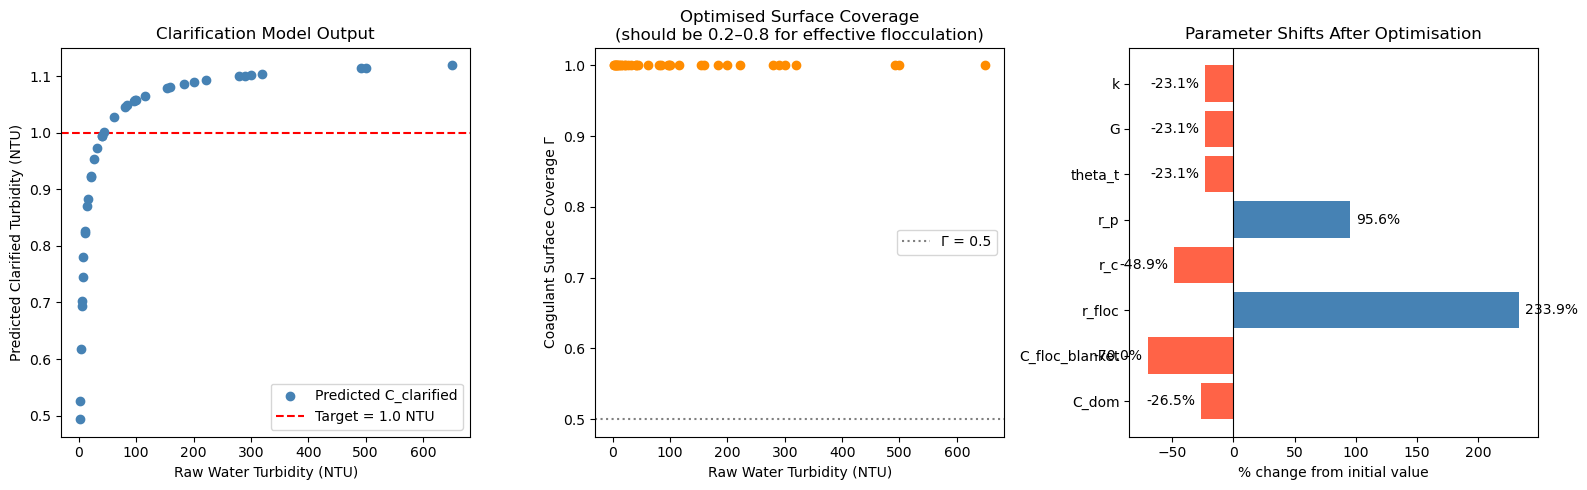

Figure saved → floc_results_v2.png


In [ ]:
# ============================================================
# CELL 7 – Plots
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Clarified turbidity vs raw turbidity ─────────────
ax = axes[0]
idx = np.argsort(C_raw_NTU)
ax.scatter(C_raw_NTU, C_clarified_NTU, label="Predicted C_clarified",
           color="steelblue", zorder=3)
ax.axhline(C_TARGET_NTU, color="red", linestyle="--",
           label=f"Target = {C_TARGET_NTU} NTU")
ax.set_xlabel("Raw Water Turbidity (NTU)")
ax.set_ylabel("Predicted Clarified Turbidity (NTU)")
ax.set_title("Clarification Model Output")
ax.legend()

# ── Plot 2: Γ (coagulant surface coverage) vs C_raw ─────────
model.eval()
with torch.no_grad():
    r_p = model.r_p.item()
    r_c = model.r_c.item()
    k_1_val = (RHO_P * r_p) / (4.0 * RHO_C * r_c)
    Gamma_np = np.clip(k_1_val * (C_coag_mgL * MGL_TO_KG_M3)
                       / (C_raw_NTU * NTU_TO_KG_M3), 0, 1)

ax = axes[1]
ax.scatter(C_raw_NTU, Gamma_np, color="darkorange")
ax.set_xlabel("Raw Water Turbidity (NTU)")
ax.set_ylabel("Coagulant Surface Coverage Γ")
ax.set_title("Optimised Surface Coverage\n(should be 0.2–0.8 for effective flocculation)")
ax.axhline(0.5, color="gray", linestyle=":", label="Γ = 0.5")
ax.legend()

# ── Plot 3: Parameter % change bar chart ─────────────────────
ax = axes[2]
names      = list(INIT.keys())
pct_change = [(optimised[n] - INIT[n]) / INIT[n] * 100 for n in names]
colors     = ["steelblue" if v >= 0 else "tomato" for v in pct_change]
bars = ax.barh(names, pct_change, color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("% change from initial value")
ax.set_title("Parameter Shifts After Optimisation")
ax.invert_yaxis()

plt.tight_layout()
# plt.savefig("floc_results_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → floc_results_v2.png")

In [17]:
# ============================================================
# CELL 8 – Sanity check: trace through the model manually
#           for one data point (the first one) so you can
#           verify each step against the PDF equations.
# ============================================================

for i in range(len(C_raw_NTU)):
    print(f"\n── Manual trace for data point {i} ─────────────────────")
    craw  = C_raw_NTU[i]
    ccoag = C_coag_mgL[i]
    print(f"  C_raw  = {craw:.1f} NTU  = {craw*NTU_TO_KG_M3:.4e} kg/m³")
    print(f"  C_coag = {ccoag:.2f} mg/L = {ccoag*MGL_TO_KG_M3:.4e} kg/m³")

    rp = optimised["r_p"]
    rc = optimised["r_c"]
    k1 = RHO_P * rp / (4 * RHO_C * rc)
    Gm  = optimised["G"]
    th  = optimised["theta_t"]
    km  = optimised["k"]
    rf  = optimised["r_floc"]
    cfb = optimised["C_floc_blanket"]

    craw_si  = craw  * NTU_TO_KG_M3
    ccoag_si = ccoag * MGL_TO_KG_M3
    gamma = min(k1 * ccoag_si / craw_si, 1.0)

    if gamma < 1 - 1e-3:
        continue

    k_pf_val = (3/(2*PI*km*Gm*th)) * ((RHO_P*PI/6)**(2/3))
    c_floc = (craw_si**(-2/3) + gamma/k_pf_val)**(-1.5)

    phi = cfb / RHO_P
    mf  = RHO_P * (4/3) * PI * rf**3
    lam = (mf/cfb)**(1/3)
    p   = gamma * PI * (3*phi/(4*PI))**(2/3)
    nb  = H_FF / lam
    c_clar = c_floc * (1-p)**nb

    print(f"\n  k_1                = {k1:.4f}  (dimensionless)")
    print(f"  Γ (coverage)       = {gamma:.4f}  (should be 0–1)")
    print(f"  k_pf               = {k_pf_val:.4e}  (kg/m³)^(2/3)")
    print(f"  C_flocculated      = {c_floc:.4e} kg/m³ = {c_floc/NTU_TO_KG_M3:.2f} NTU")
    print(f"  φ_floc             = {phi:.4e}  (volume fraction of floc blanket)")
    print(f"  m_floc             = {mf:.4e} kg")
    print(f"  Λ (spacing)        = {lam*100:.2f} cm")
    print(f"  p (removal/box)    = {p:.4e}")
    print(f"  n_boxes (h_ff/Λ)   = {nb:.1f}")
    print(f"  C_clarified        = {c_clar:.4e} kg/m³ = {c_clar/NTU_TO_KG_M3:.3f} NTU")
    print(f"  Target             = {C_TARGET_NTU:.1f} NTU")


── Manual trace for data point 0 ─────────────────────
  C_raw  = 1.9 NTU  = 2.8224e-03 kg/m³
  C_coag = 6.00 mg/L = 6.0000e-03 kg/m³

  k_1                = 28.0061  (dimensionless)
  Γ (coverage)       = 1.0000  (should be 0–1)
  k_pf               = 1.5032e-02  (kg/m³)^(2/3)
  C_flocculated      = 7.9426e-04 kg/m³ = 0.54 NTU
  φ_floc             = 3.9986e-04  (volume fraction of floc blanket)
  m_floc             = 2.3389e-04 kg
  Λ (spacing)        = 7.31 cm
  p (removal/box)    = 6.5619e-03
  n_boxes (h_ff/Λ)   = 13.7
  C_clarified        = 7.2582e-04 kg/m³ = 0.494 NTU
  Target             = 1.0 NTU

── Manual trace for data point 1 ─────────────────────
  C_raw  = 2.2 NTU  = 3.2928e-03 kg/m³
  C_coag = 7.00 mg/L = 7.0000e-03 kg/m³

  k_1                = 28.0061  (dimensionless)
  Γ (coverage)       = 1.0000  (should be 0–1)
  k_pf               = 1.5032e-02  (kg/m³)^(2/3)
  C_flocculated      = 8.4698e-04 kg/m³ = 0.58 NTU
  φ_floc             = 3.9986e-04  (volume fraction of f

In [14]:
# ============================================================
# CELL X – Invert model to get required coagulant dose
# ============================================================

predicted_dose_mgL = []

for i in range(N):
    C_raw_val = C_raw_t[i].unsqueeze(0)

    # Initialize guess at actual dose
    dose = torch.tensor([C_coag_t[i].item()], requires_grad=True)

    optimiser_dose = torch.optim.Adam([dose], lr=1e-2)

    for _ in range(500):
        optimiser_dose.zero_grad()

        C_pred = model(C_raw_val, dose)
        loss = (C_pred - C_target_t[i])**2

        loss.backward()
        optimiser_dose.step()

        # Keep dose physically meaningful
        dose.data.clamp_(min=1e-8)

    predicted_dose_mgL.append(dose.item() / MGL_TO_KG_M3)

predicted_dose_mgL = np.array(predicted_dose_mgL)

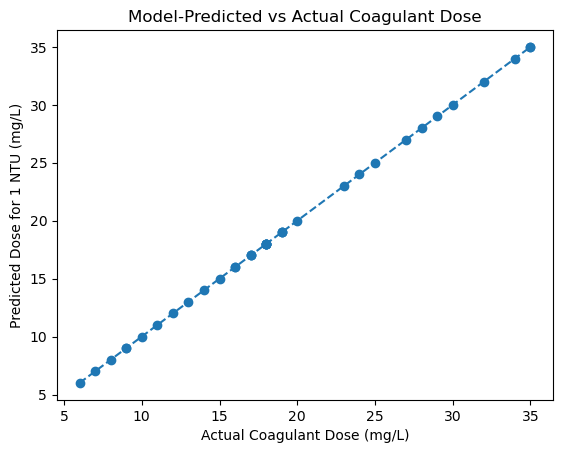

In [15]:
# ============================================================
# CELL Y – Scatter plot comparison
# ============================================================

plt.figure()

plt.scatter(C_coag_mgL, predicted_dose_mgL)

# Optional: 1:1 reference line
min_val = min(C_coag_mgL.min(), predicted_dose_mgL.min())
max_val = max(C_coag_mgL.max(), predicted_dose_mgL.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')

plt.xlabel("Actual Coagulant Dose (mg/L)")
plt.ylabel("Predicted Dose for 1 NTU (mg/L)")
plt.title("Model-Predicted vs Actual Coagulant Dose")

plt.show()